# Capstone Report Notebook Shell

Use this notebook as the **narrative notebook** for your capstone.

This notebook is **not** the main engine. The main engine is:

- `run_pipeline.py`
- `dashboard_app.py`

Recommended workflow:

1. update `fund_manager_control.xlsx`
2. run `python run_pipeline.py`
3. launch `streamlit run dashboard_app.py`
4. use this notebook to organize analysis, interpretation, and report-ready tables/figures


## 0. Setup and Project Paths

This cell sets project paths and loads the most common output tables.


In [77]:

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TABLES_DIR exists:", TABLES_DIR.exists())
print("FIGURES_DIR exists:", FIGURES_DIR.exists())

def safe_read_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"[missing] {path.name}")
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception as exc:
        print(f"[error] {path.name}: {exc}")
        return pd.DataFrame()

tables = {
    "inputs": safe_read_csv(TABLES_DIR / "tbl_inputs.csv"),
    "constraints": safe_read_csv(TABLES_DIR / "tbl_constraints.csv"),
    "inherited": safe_read_csv(TABLES_DIR / "tbl_inherited_fund.csv"),
    "candidates": safe_read_csv(TABLES_DIR / "tbl_candidates.csv"),
    "portfolio": safe_read_csv(TABLES_DIR / "tbl_portfolio_summary.csv"),
    "performance": safe_read_csv(TABLES_DIR / "tbl_performance_summary.csv"),
    "legacy_daily": safe_read_csv(TABLES_DIR / "tbl_legacy_fund_daily.csv"),
    "candidate_screen": safe_read_csv(TABLES_DIR / "tbl_candidate_screen.csv"),
    "static_compare": safe_read_csv(TABLES_DIR / "tbl_backtest_legacy_static_benchmark.csv"),
    "active_compare": safe_read_csv(TABLES_DIR / "tbl_backtest_legacy_static_active_benchmark.csv"),
    "factor_capm": safe_read_csv(TABLES_DIR / "tbl_factor_capm_summary.csv"),
    "factor_rolling_beta": safe_read_csv(TABLES_DIR / "tbl_factor_rolling_beta.csv"),
    "scenario_mc_summary": safe_read_csv(TABLES_DIR / "tbl_scenario_monte_carlo_summary.csv"),
    "scenario_stress": safe_read_csv(TABLES_DIR / "tbl_scenario_stress_summary.csv"),
    "manifest": safe_read_csv(TABLES_DIR / "tbl_project_manifest.csv"),
}
list(tables.keys())


PROJECT_ROOT: /Users/baileybinando/Desktop/BFIN491/BFIN491project
TABLES_DIR exists: True
FIGURES_DIR exists: True


['inputs',
 'constraints',
 'inherited',
 'candidates',
 'portfolio',
 'performance',
 'legacy_daily',
 'candidate_screen',
 'static_compare',
 'active_compare',
 'factor_capm',
 'factor_rolling_beta',
 'scenario_mc_summary',
 'scenario_stress',
 'manifest']

## 1. Project Setup and Workbook Inputs

Use this section to summarize:
- project title
- team members
- benchmark
- rebalance settings
- active rule
- key assumptions


In [78]:

tables["inputs"]


,Parameter,Value
0,project_title,Fund Management Dashboard Capstone
1,team_name,BlackFin Inc.
2,decision_date,2020-01-01 00:00:00
3,fund_inception,2010-01-01 00:00:00
4,oos_start,2020-01-01 00:00:00
5,oos_end,2025-12-31 00:00:00
6,market_benchmark,SPY
7,price_source,yfinance
8,macro_source,FRED
9,risk_free_proxy,DGS3MO


In [79]:

tables["constraints"]


,Parameter,Value
0,long_only,1
1,fully_invested,1
2,rebalance_frequency,Monthly
3,estimation_window_months,36
4,max_weight,0.25
5,min_weight,0
6,turnover_cap,0.2
7,transaction_cost_bps,10
8,active_rule,optimizer
9,optimizer_objective,max_sharpe


### Notes for the report
- What is the project title?
- What benchmark are you using?
- What active rule are you using?
- What constraints matter most for implementation?


## 2. Inherited Fund Audit

Required goals:
- reconstruct the inherited fund
- explain concentration
- show historical performance and drawdown
- identify weaknesses before redesign


In [80]:
from IPython.display import Image, display
import subprocess, sys

# Auto-generate audit outputs if not already present
audit_csv = TABLES_DIR / "tbl_audit_stock_stats.csv"
if not audit_csv.exists():
    print("Running inherited_fund_analysis.py to generate audit outputs...")
    result = subprocess.run(
        [sys.executable, str(PROJECT_ROOT / "inherited_fund_analysis.py")],
        capture_output=True, text=True,
    )
    print(result.stdout[-2000:] if result.stdout else "")
    if result.returncode != 0:
        print("ERROR:", result.stderr[-1000:])

audit_stats = safe_read_csv(audit_csv)
weights_snapshot = safe_read_csv(TABLES_DIR / "tbl_legacy_weights_snapshot.csv")
print(f"Audit stats loaded: {audit_stats.shape[0]} stocks")

Audit stats loaded: 10 stocks


### Holdings at Inception (2010-01-01)

The fund was seeded with $1,000,000 equally split across 10 stocks.

In [81]:
tables["inherited"][["legacy_ticker", "company_name", "sector", "initial_weight_2010"]]

,legacy_ticker,company_name,sector,initial_weight_2010
0,AAPL,Apple Inc.,Technology,0.1
1,AMZN,"Amazon.com, Inc.",Consumer Discretionary,0.1
2,BRK-B,Berkshire Hathaway Inc.,Financials,0.1
3,CMCSA,Comcast Corporation,Communication Services,0.1
4,GOOG,Alphabet Inc.,Communication Services,0.1
5,KO,The Coca-Cola Company,Consumer Staples,0.1
6,MSFT,Microsoft Corporation,Technology,0.1
7,ORCL,Oracle Corporation,Technology,0.1
8,WFC,Wells Fargo & Company,Financials,0.1
9,XOM,Exxon Mobil Corporation,Energy,0.1


### Per-Stock Statistics (In-Sample: 2010–2019)

All metrics use only information available through 2019-12-31.

| Column | Meaning |
|---|---|
| `total_return` / `ann_return` | Cumulative and annualized return over the full in-sample window |
| `ann_vol` | Annualized daily return volatility |
| `sharpe` / `sortino` | Risk-adjusted return (Sharpe = return/vol; Sortino = return/downside vol) |
| `max_drawdown` | Worst peak-to-trough loss |
| `alpha_ann` | Annualized CAPM alpha vs SPY — value added beyond passive exposure |
| `beta` | Market sensitivity (>1 = amplifies SPY moves) |
| `corr_to_spy` / `avg_pairwise_corr` | Correlation to benchmark and average correlation to the other 9 holdings |
| `return_1y` / `return_3y` | Return over the final 1 and 3 years before the decision date |
| `weight_start` / `weight_end` | Initial 10% equal weight vs drifted weight at 2019-12-31 |

In [82]:
fmt = audit_stats.copy()
for col in ["total_return","ann_return","ann_vol","max_drawdown","return_1y","return_3y","weight_start","weight_end"]:
    if col in fmt.columns:
        fmt[col] = fmt[col].map(lambda v: f"{v:.1%}" if pd.notna(v) else "—")
for col in ["sharpe","sortino","beta","r_squared","corr_to_spy","avg_pairwise_corr"]:
    if col in fmt.columns:
        fmt[col] = fmt[col].map(lambda v: f"{v:.2f}" if pd.notna(v) else "—")
if "alpha_ann" in fmt.columns:
    fmt["alpha_ann"] = fmt["alpha_ann"].map(lambda v: f"{v:.2%}" if pd.notna(v) else "—")
fmt

,ticker,total_return,ann_return,ann_vol,sharpe,sortino,max_drawdown,alpha_ann,beta,r_squared,corr_to_spy,avg_pairwise_corr,return_1y,return_3y,weight_start,weight_end
0,AAPL,1003.9%,27.2%,25.7%,1.06,1.47,-43.8%,13.29%,1.04,0.35,0.59,0.38,89.0%,164.7%,10.0%,20.3%
1,AMZN,1280.0%,30.1%,31.0%,0.97,1.39,-34.1%,14.90%,1.20,0.32,0.57,0.39,23.0%,145.2%,10.0%,25.4%
2,BRK-B,242.0%,13.1%,18.2%,0.72,1.06,-24.4%,0.65%,0.98,0.63,0.79,0.51,10.9%,38.3%,10.0%,6.3%
3,CMCSA,535.1%,20.3%,22.0%,0.92,1.35,-28.4%,7.93%,0.96,0.41,0.64,0.41,34.0%,37.4%,10.0%,11.7%
4,GOOG,328.3%,15.7%,24.4%,0.64,0.92,-30.1%,3.25%,1.05,0.40,0.63,0.44,29.1%,70.1%,10.0%,7.9%
5,KO,164.1%,10.2%,14.8%,0.69,0.93,-13.8%,3.18%,0.56,0.31,0.56,0.36,20.6%,46.1%,10.0%,4.9%
6,MSFT,547.4%,20.6%,22.7%,0.91,1.29,-26.4%,6.77%,1.07,0.48,0.69,0.47,57.6%,166.0%,10.0%,11.9%
7,ORCL,142.0%,9.3%,23.3%,0.40,0.51,-31.7%,-3.01%,1.08,0.46,0.68,0.44,19.3%,43.7%,10.0%,4.4%
8,WFC,155.7%,9.9%,24.0%,0.41,0.59,-32.2%,-4.32%,1.23,0.56,0.75,0.46,21.4%,5.8%,10.0%,4.7%
9,XOM,39.4%,3.4%,18.5%,0.18,0.26,-31.5%,-7.28%,0.91,0.52,0.72,0.45,7.2%,-13.0%,10.0%,2.6%


### Individual Stock Returns vs SPY (2010–2019)

Each subplot shows cumulative growth of $1 for that stock (blue) vs SPY (gray dashed).

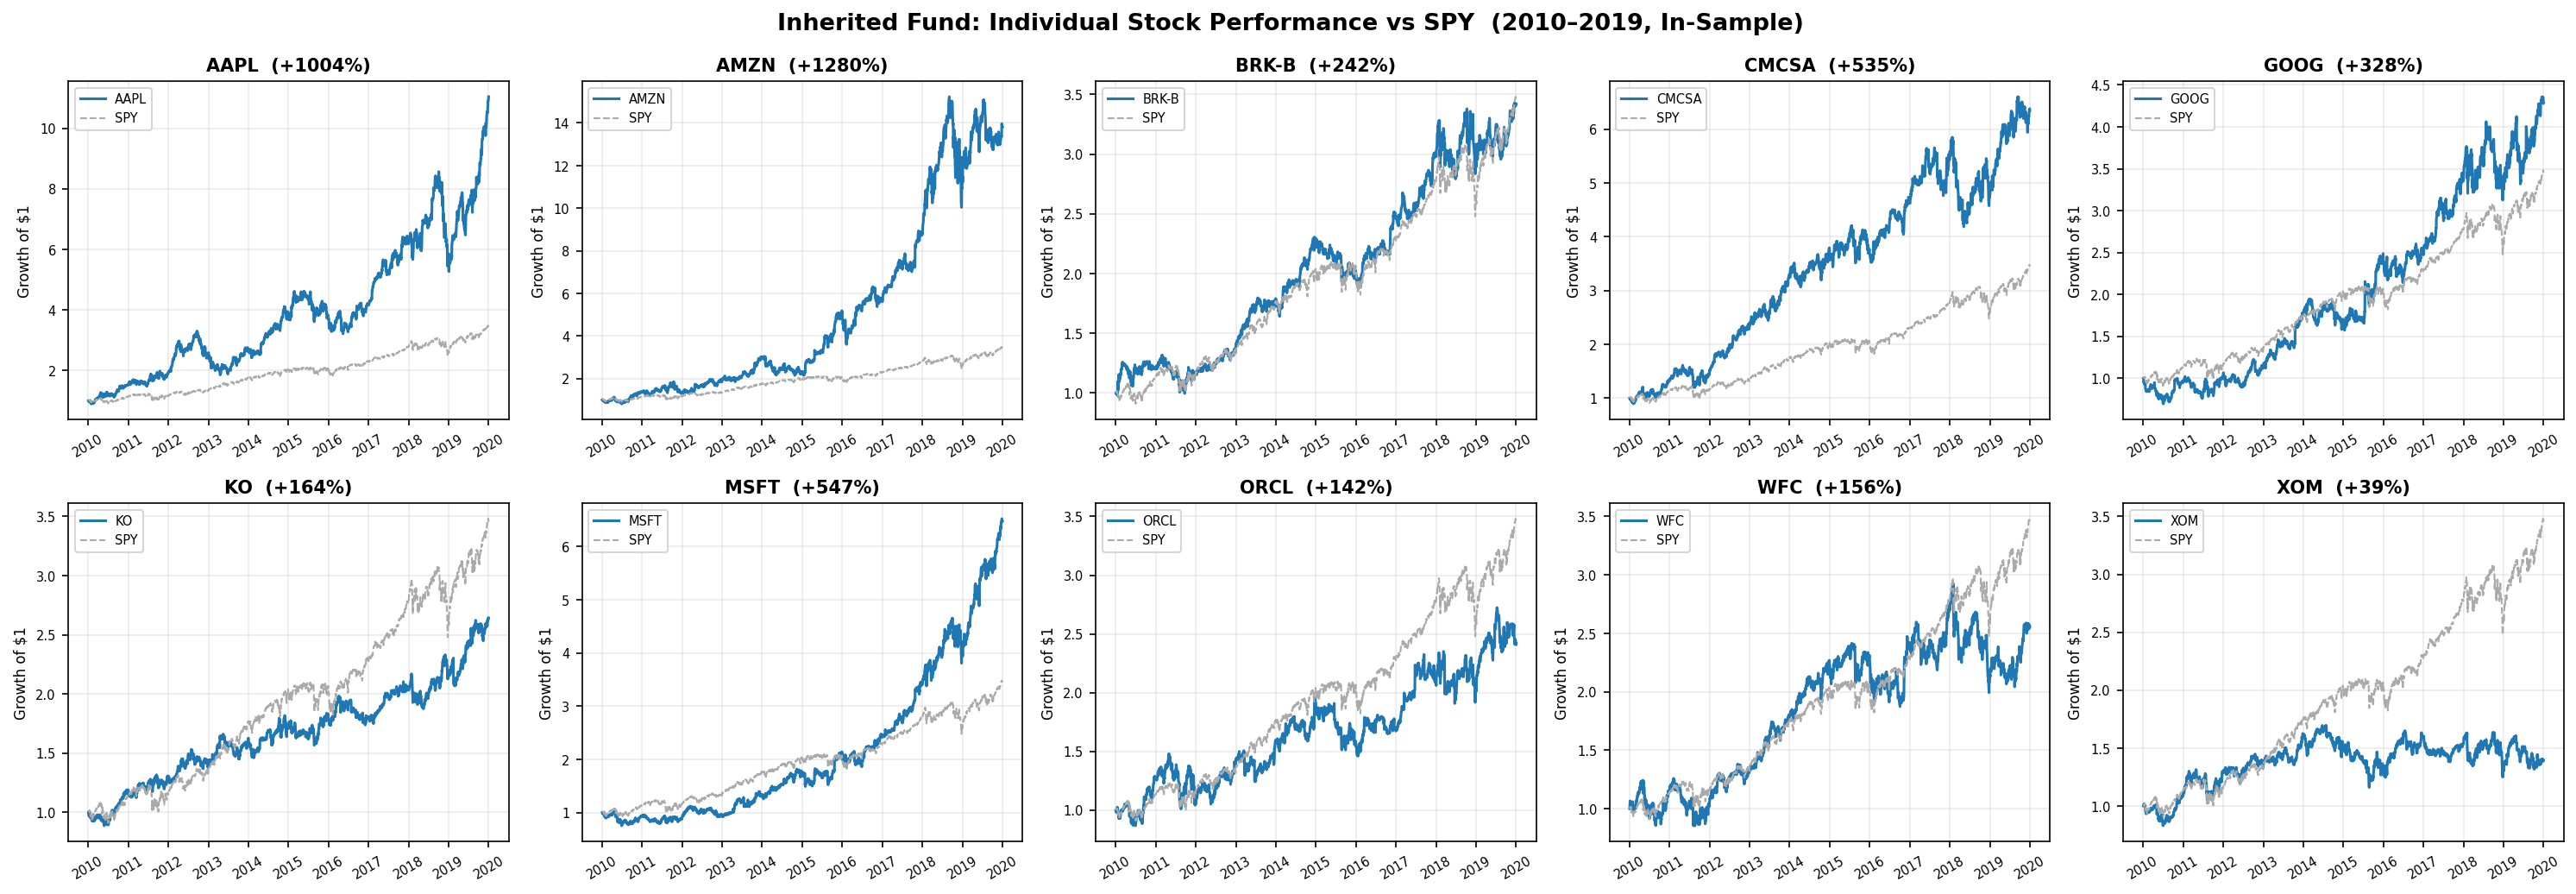

In [83]:
display(Image(str(FIGURES_DIR / "fig_audit_grid_returns.png"), width=1100))

### Risk vs Return (2010–2019)

Each stock plotted by annualized volatility (x) and annualized return (y). SPY is the orange star benchmark reference.

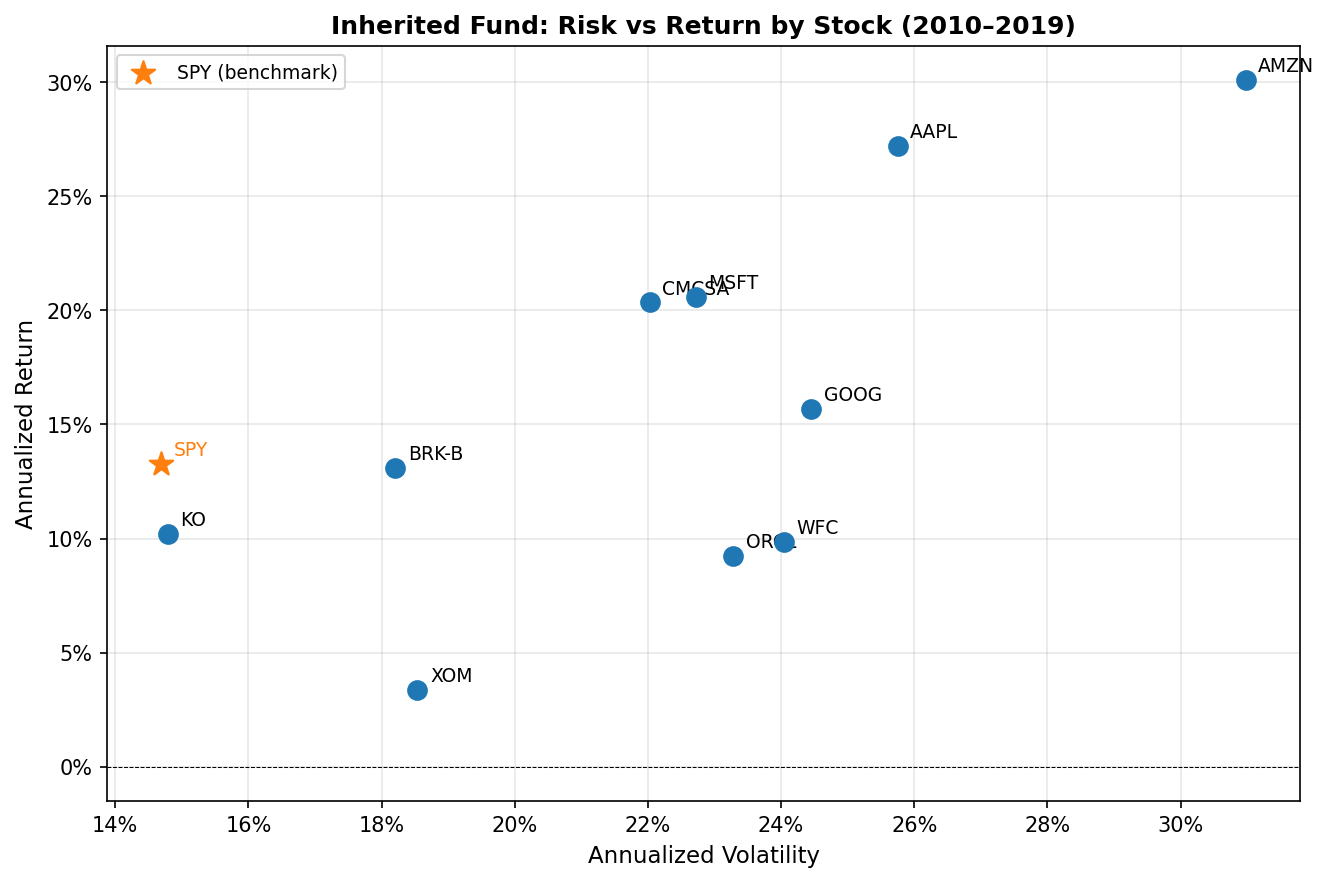

In [84]:
display(Image(str(FIGURES_DIR / "fig_audit_risk_return.png"), width=750))

### Weight Drift — Inception to Decision Date (2019-12-31)

Equal-weight start (10% each) vs how each position drifted by the manager handover date. Stocks that outperformed grew; underperformers shrank.

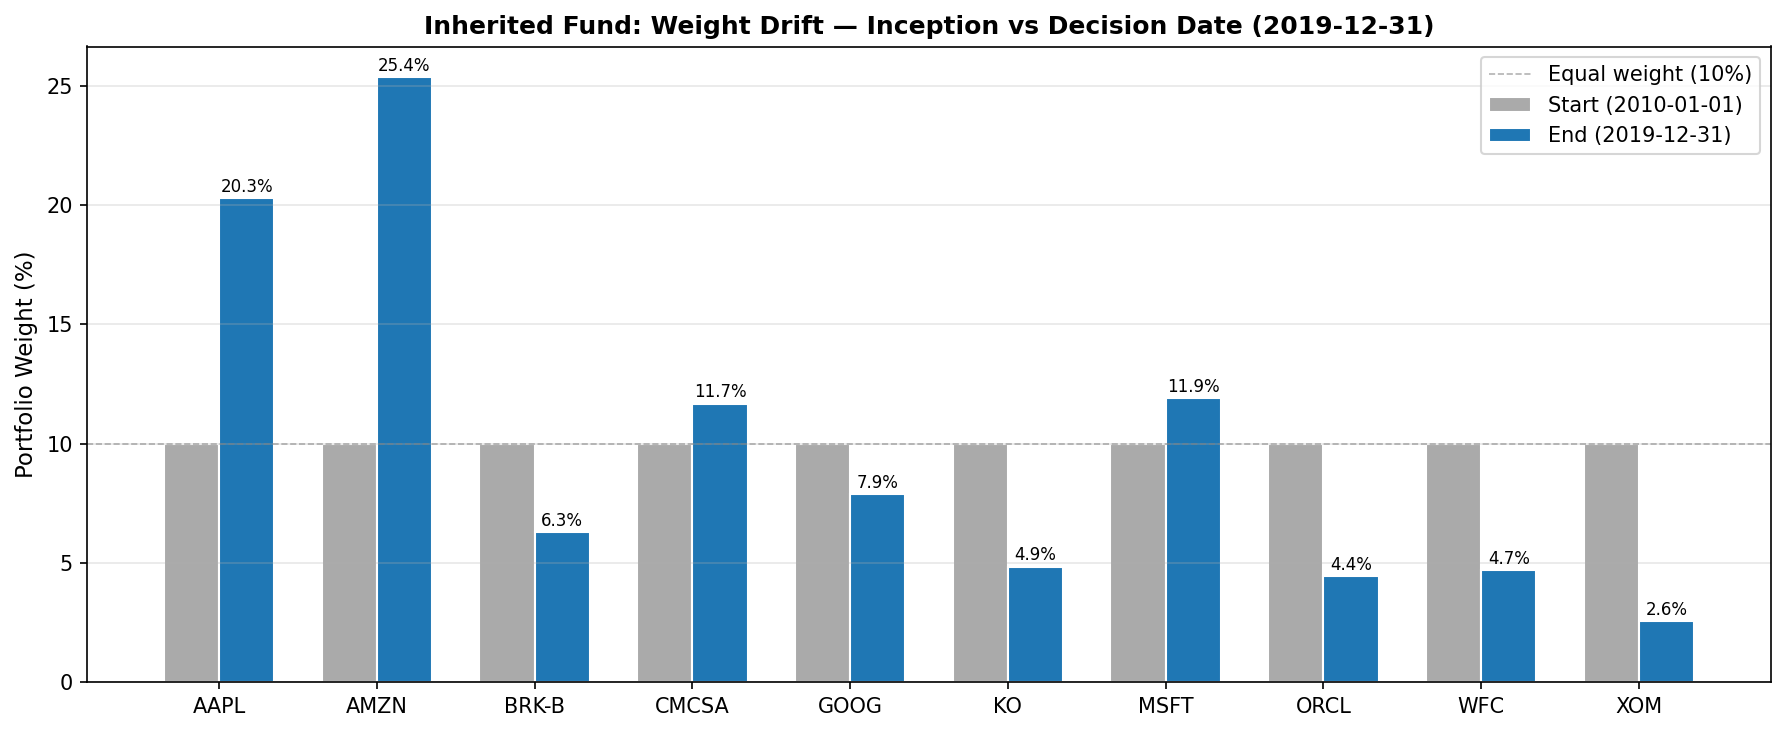

In [85]:
display(Image(str(FIGURES_DIR / "fig_audit_weight_drift.png"), width=900))

### Pairwise Correlation Heatmap (2010–2019)

Red = highly correlated pairs (less diversification benefit). Green = lower correlation (more independent movement).

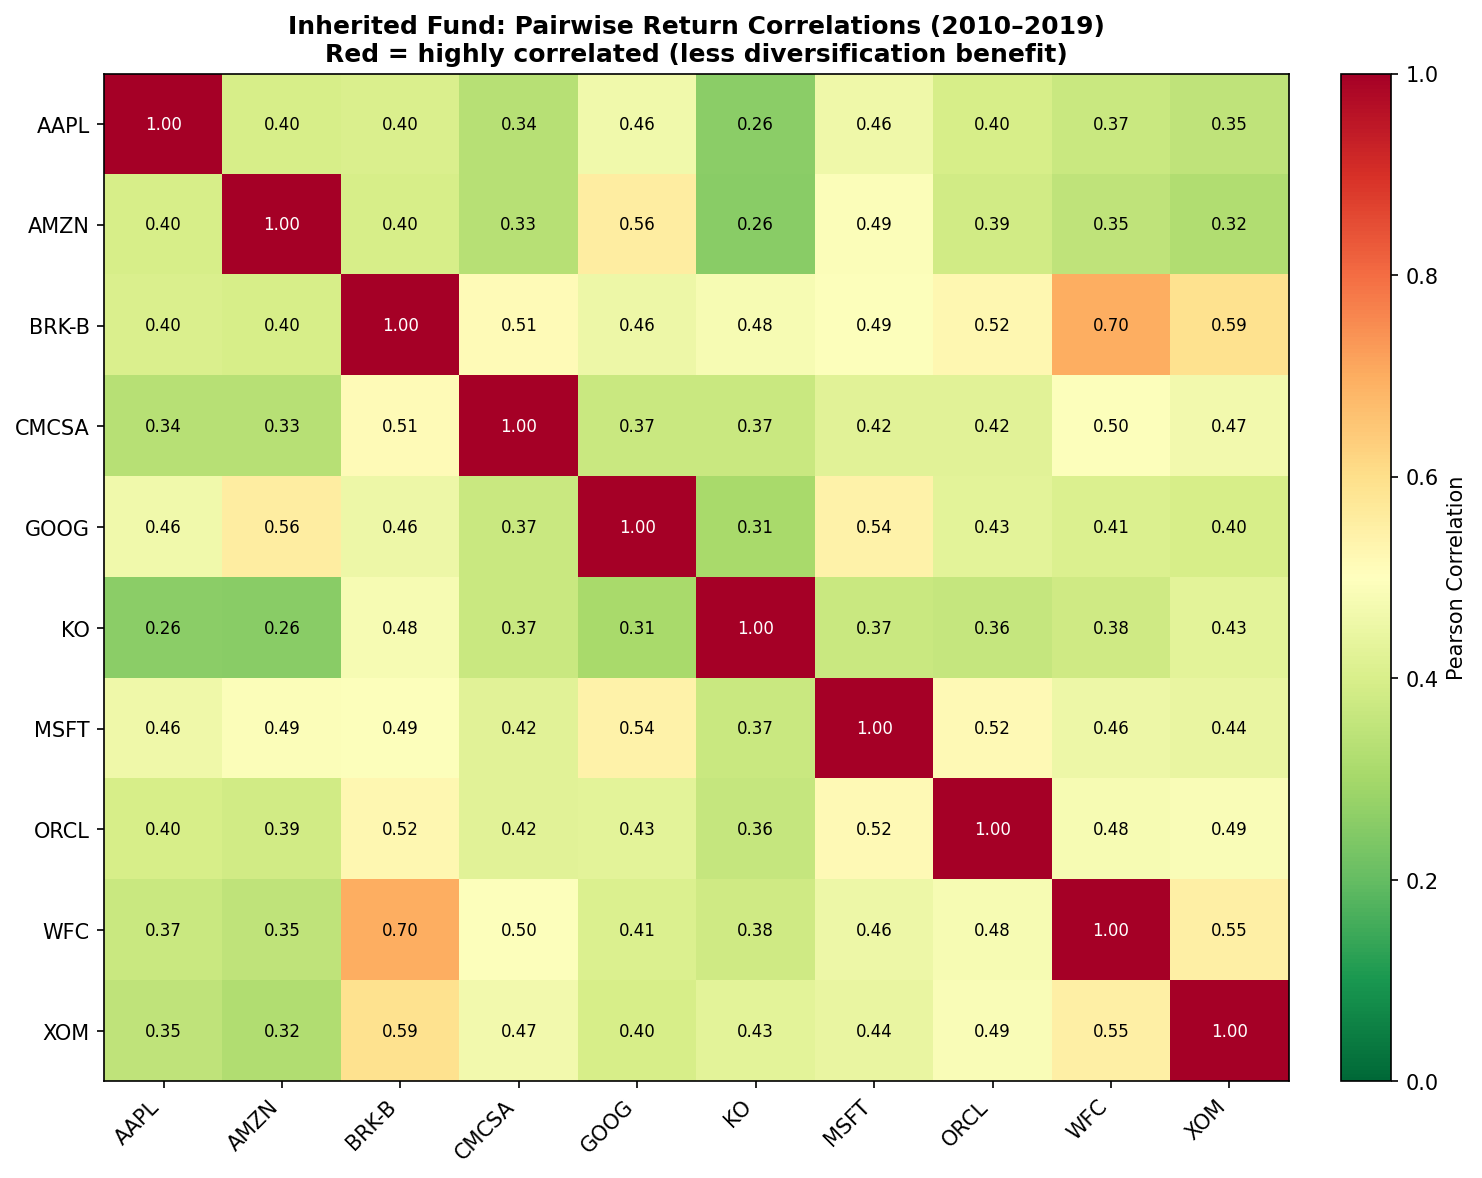

In [86]:
display(Image(str(FIGURES_DIR / "fig_audit_correlation_heatmap.png"), width=750))

### Overall Legacy Fund Performance (Full Period)

In [87]:
tables["performance"]

,portfolio,ending_value,total_return,ann_return,ann_vol,sharpe,sortino,max_drawdown,turnover
0,Legacy Fund,1.526160e+07,1.757095,0.184686,0.243281,0.759146,1.002198,-0.313778,0.000000
1,Revised Static Fund,1.404874e+07,1.537985,0.168406,0.219082,0.768688,0.981921,-0.273907,0.000000
2,Revised Active Fund,1.410007e+07,1.547259,0.169118,0.213334,0.792738,1.004153,-0.278292,0.021466
3,Benchmark,1.267957e+07,1.290636,0.148555,0.207413,0.716228,0.880248,-0.337172,0.000000


### Interpretation prompts
- Which inherited names became dominant by January 2020?
- How concentrated did the legacy fund become?
- What are the biggest risks visible in the inherited fund?
- Why might a redesign be justified?


## 3. Candidate Stock Analysis

Required goals:
- research 5–10 candidates
- show screening logic
- justify inclusion or rejection


In [88]:

tables["candidates"]


,candidate_ticker,download_ticker,company_name,sector_theme,thesis_1line,screening_note,add_decision,selected_for_final,target_weight_2020,notes
0,V,V,Visa Inc.,Financials / Payments,Global cashless payment network with near-mono...,Passes all 4 screens; network effect moat; bes...,Add,Yes,0.08,"Selected: largest global payment network, high..."
1,MA,MA,Mastercard Incorporated,Financials / Payments,Second-largest global payment network with eco...,Passes all 4 screens; network effect moat; rej...,Reject,No,0.00,Rejected: passes all rules but loses best-in-c...
2,JPM,JPM,JPMorgan Chase & Co.,Financials / Payments,Largest U.S. bank by assets with diversified f...,Passes size and profitability screens; strong ...,Reject,No,0.00,Rejected: moat present but banking model adds ...
3,WMT,WMT,Walmart Inc.,Consumer Staples,Recession-proof retailer with cost-advantage m...,Passes all 4 screens; cost advantage + brand m...,Add,Yes,0.08,"Selected: largest global retailer, superior sc..."
4,COST,COST,Costco Wholesale Corporation,Consumer Staples,Membership-model warehouse retailer with excep...,Passes all 4 screens; membership moat is stron...,Reject,No,0.00,Rejected: strong candidate but loses best-in-c...
5,TGT,TGT,Target Corporation,Consumer Staples,Mid-size U.S. retailer with strong private-lab...,Fails size screen — market cap ~$44B in Jan 20...,Reject,No,0.00,Rejected: fails Rule 1 (size) — market cap bel...
6,CVX,CVX,Chevron Corporation,Energy,Best-balance-sheet integrated oil major; oil d...,Passes all 4 screens; regulatory license + sca...,Add,Yes,0.08,Selected: integrated major with superior balan...
7,XOM,XOM,Exxon Mobil Corporation,Energy,Largest U.S. integrated oil major; held in leg...,Passes size and profitability screens; regulat...,Reject,No,0.00,Rejected: passes all rules but loses best-in-c...
8,COP,COP,ConocoPhillips,Energy,Large U.S. exploration and production company ...,Passes size screen; fails moat screen — E&P-on...,Reject,No,0.00,Rejected: fails Rule 3 (moat) — no integrated ...
9,NEE,NEE,NextEra Energy Inc.,Utilities,Regulated Florida utility monopoly and worlds ...,Passes all 4 screens; regulatory license moat;...,Add,Yes,0.08,Selected: only utility combining regulated mon...


In [89]:

tables["candidate_screen"].sort_values(by=[c for c in ["sharpe_pre2020", "ann_return_pre2020"] if c in tables["candidate_screen"].columns], ascending=False).head(10)


,candidate_ticker,download_ticker,company_name,sector_theme,thesis_1line,screening_note,add_decision,selected_for_final,status,first_date,...,sharpe_pre2020,max_drawdown_pre2020,return_1y_pre2020,return_3m_pre2020,vol_63d_pre2020,current_drawdown_pre2020,corr_to_legacy_pre2020,corr_to_benchmark_pre2020,beta_to_benchmark_pre2020,notes
0,NEE,NEE,NextEra Energy Inc.,Utilities,Regulated Florida utility monopoly and worlds ...,Passes all 4 screens; regulatory license moat;...,Add,Yes,ok,2010-01-04,...,1.250320,-0.144226,0.426859,0.049241,0.145185,-0.002266,0.380373,0.453095,0.497297,Selected: only utility combining regulated mon...
1,UNH,UNH,UnitedHealth Group Inc.,Healthcare,Largest U.S. health insurer plus Optum data an...,Passes all 4 screens; switching cost + network...,Add,Yes,ok,2010-01-04,...,1.181066,-0.239802,0.200031,0.358640,0.239050,-0.006723,0.519896,0.580038,0.901505,Selected: highest EPS growth in healthcare; sw...
5,COST,COST,Costco Wholesale Corporation,Consumer Staples,Membership-model warehouse retailer with excep...,Passes all 4 screens; membership moat is stron...,Reject,No,ok,2010-01-04,...,1.138109,-0.220173,0.457007,0.037434,0.111886,-0.036991,0.526480,0.563726,0.687468,Rejected: strong candidate but loses best-in-c...
6,MA,MA,Mastercard Incorporated,Financials / Payments,Second-largest global payment network with eco...,Passes all 4 screens; network effect moat; rej...,Reject,No,ok,2010-01-04,...,1.127511,-0.281025,0.591580,0.103390,0.196042,-0.007149,0.675482,0.698319,1.201809,Rejected: passes all rules but loses best-in-c...
2,V,V,Visa Inc.,Financials / Payments,Global cashless payment network with near-mono...,Passes all 4 screens; network effect moat; bes...,Add,Yes,ok,2010-01-04,...,1.061634,-0.319945,0.433270,0.079894,0.162754,-0.007867,0.628488,0.657241,1.047424,"Selected: largest global payment network, high..."
7,SO,SO,Southern Company,Utilities,Regulated utility serving the Southeast with a...,Passes size and profitability screens; regulat...,Reject,No,ok,2010-01-04,...,0.832587,-0.192955,0.516529,0.039744,0.150756,-0.002505,0.269315,0.343398,0.332873,Rejected: passes all rules but loses best-in-c...
8,JNJ,JNJ,Johnson & Johnson,Healthcare,Diversified healthcare conglomerate spanning p...,Passes all 4 screens; brand + IP moat is stron...,Reject,No,ok,2010-01-04,...,0.786680,-0.182829,0.162201,0.129938,0.196407,-0.003892,0.537457,0.621294,0.635117,Rejected: strong moat but lower EPS growth; li...
9,DUK,DUK,Duke Energy Corporation,Utilities,Large regulated utility serving 7.7M customers...,Passes size and profitability screens; regulat...,Reject,No,ok,2010-01-04,...,0.745630,-0.230800,0.102882,-0.041542,0.132166,-0.051208,0.312409,0.389607,0.390959,Rejected: passes all rules but loses best-in-c...
3,WMT,WMT,Walmart Inc.,Consumer Staples,Recession-proof retailer with cost-advantage m...,Passes all 4 screens; cost advantage + brand m...,Add,Yes,ok,2010-01-04,...,0.632041,-0.364352,0.301630,0.012924,0.108010,-0.020119,0.389218,0.448267,0.526291,"Selected: largest global retailer, superior sc..."
10,JPM,JPM,JPMorgan Chase & Co.,Financials / Payments,Largest U.S. bank by assets with diversified f...,Passes size and profitability screens; strong ...,Reject,No,ok,2010-01-04,...,0.610151,-0.396627,0.472571,0.216068,0.157061,0.000000,0.666127,0.765706,1.306155,Rejected: moat present but banking model adds ...


### Interpretation prompts
- What is your candidate universe?
- Why do these names fit your theme or diversification goal?
- Which candidates look strongest by the pre-2020 screen?
- Which names did you reject, and why?


## 4. Revised Fund Design

Required goals:
- explain which original names were kept or dropped
- explain which new names were added
- explain target weights


In [90]:

tables["portfolio"]


,ticker,source,decision,selected_for_final,static_weight,latest_active_weight,notes
0,AAPL,Inherited,Keep,Yes,0.15,0.147127,NaN
1,AMZN,Inherited,Keep,Yes,0.15,0.150881,NaN
2,CMCSA,Inherited,Keep,Yes,0.10,0.106405,NaN
3,GOOG,Inherited,Keep,Yes,0.10,0.101797,NaN
4,MSFT,Inherited,Keep,Yes,0.10,0.100061,NaN
5,V,Candidate,Add,Yes,0.08,0.084572,"Selected: largest global payment network, high..."
6,WMT,Candidate,Add,Yes,0.08,0.083930,"Selected: largest global retailer, superior sc..."
7,CVX,Candidate,Add,Yes,0.08,0.076654,Selected: integrated major with superior balan...
8,NEE,Candidate,Add,Yes,0.08,0.071970,Selected: only utility combining regulated mon...
9,UNH,Candidate,Add,Yes,0.08,0.076601,Selected: highest EPS growth in healthcare; sw...


### Interpretation prompts
- Which inherited holdings did you keep?
- Which inherited holdings did you drop?
- Which new stocks entered the final 10-stock fund?
- Are the weights intuitive, or are they too concentrated?


## 5. Backtest and Performance Evaluation

Required comparison:
- Legacy Fund
- Revised Static Fund
- Revised Active Fund
- benchmark


In [91]:

tables["static_compare"].head()


,date,legacy_growth_of_1_oos,legacy_drawdown_oos,revised_static_growth_of_1,revised_static_drawdown,benchmark_growth_of_1,benchmark_drawdown
0,2020-01-02,5.535390,0.000000,1.000000,0.000000,1.000000,0.000000
1,2020-01-03,5.483419,-0.009389,0.992333,-0.007667,0.992428,-0.007572
2,2020-01-06,5.522765,-0.002281,0.998030,-0.001970,0.996214,-0.003786
3,2020-01-07,5.514553,-0.003764,0.995206,-0.004794,0.993413,-0.006587
4,2020-01-08,5.542013,0.000000,1.001632,0.000000,0.998707,-0.001293


In [92]:

tables["active_compare"].head()


,date,legacy_growth_of_1_oos,legacy_drawdown_oos,revised_static_growth_of_1,revised_static_drawdown,revised_active_growth_of_1,revised_active_drawdown,benchmark_growth_of_1,benchmark_drawdown
0,2020-01-02,5.535390,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
1,2020-01-03,5.483419,-0.009389,0.992333,-0.007667,0.992333,-0.007667,0.992428,-0.007572
2,2020-01-06,5.522765,-0.002281,0.998030,-0.001970,0.998030,-0.001970,0.996214,-0.003786
3,2020-01-07,5.514553,-0.003764,0.995206,-0.004794,0.995206,-0.004794,0.993413,-0.006587
4,2020-01-08,5.542013,0.000000,1.001632,0.000000,1.001632,0.000000,0.998707,-0.001293


In [93]:

tables["performance"]


,portfolio,ending_value,total_return,ann_return,ann_vol,sharpe,sortino,max_drawdown,turnover
0,Legacy Fund,1.526160e+07,1.757095,0.184686,0.243281,0.759146,1.002198,-0.313778,0.000000
1,Revised Static Fund,1.404874e+07,1.537985,0.168406,0.219082,0.768688,0.981921,-0.273907,0.000000
2,Revised Active Fund,1.410007e+07,1.547259,0.169118,0.213334,0.792738,1.004153,-0.278292,0.021466
3,Benchmark,1.267957e+07,1.290636,0.148555,0.207413,0.716228,0.880248,-0.337172,0.000000


### Interpretation prompts
- Did the static redesign improve the inherited fund?
- Did active management improve the static redesign?
- How large are the tradeoffs in return, risk, drawdown, and turnover?
- Are any results too good to trust without caution?


## 6. Factor / Regression Analysis

Required goal:
- explain portfolio behavior with at least one factor/regression-based section


In [94]:

tables["factor_capm"]


,portfolio,n_obs,alpha_daily,alpha_ann,beta,alpha_tstat,alpha_pvalue,beta_tstat,beta_pvalue,r_squared,corr_to_benchmark,market_proxy,risk_free_assumption,notes
0,Legacy Fund,1508,0.000126,0.031635,1.064890,0.755869,0.449846,83.847063,0.0,0.823578,0.907512,benchmark_return,0.0,Starter CAPM uses the benchmark daily return a...
1,Revised Static Fund,1508,0.000086,0.021643,0.987221,0.678574,0.497512,102.000008,0.0,0.873552,0.934640,benchmark_return,0.0,Starter CAPM uses the benchmark daily return a...
2,Revised Active Fund,1508,0.000097,0.024383,0.966194,0.814200,0.415659,106.317730,0.0,0.882431,0.939378,benchmark_return,0.0,Starter CAPM uses the benchmark daily return a...


In [95]:

tables["factor_rolling_beta"].head()


,date,portfolio,rolling_beta,window
0,2020-01-02,Legacy Fund,NaN,63
1,2020-01-03,Legacy Fund,NaN,63
2,2020-01-06,Legacy Fund,NaN,63
3,2020-01-07,Legacy Fund,NaN,63
4,2020-01-08,Legacy Fund,NaN,63


### Interpretation prompts
- What do alpha and beta suggest for each portfolio?
- How stable or unstable is beta over time?
- Does the active fund materially change market exposure?


## 7. Scenario / Stress Analysis

Required goal:
- show at least one simulation or stress-testing block


In [96]:

tables["scenario_mc_summary"]


,portfolio,horizon_days,n_sims,mean_terminal_return,median_terminal_return,pct_05_terminal_return,pct_01_terminal_return,var_95,cvar_95,prob_loss
0,Revised Static Fund,252,2000,0.192033,0.165155,-0.178901,-0.282911,0.178901,0.242474,0.2300
1,Revised Active Fund,252,2000,0.199561,0.167962,-0.165018,-0.266413,0.165018,0.231865,0.2155


In [97]:

tables["scenario_stress"]


,scenario,scenario_date,scenario_type,benchmark_return,equal_weight_universe_return,static_portfolio_impact,active_portfolio_impact,notes
0,COVID Crash Day,2020-03-16,historical,-0.115256,-0.115256,-0.111810,-0.111235,Uses actual selected-universe daily returns on...
1,Worst OOS Day,2020-03-16,historical,-0.115256,-0.115256,-0.111810,-0.111235,Uses the worst benchmark-proxy day in the out-...
2,Worst 21-Day Window,2020-03-23,historical_window,-0.278584,-0.273426,-0.260648,-0.258181,Uses compounded selected-universe returns over...
3,Parallel -10% Shock,NaN,synthetic,-0.100000,-0.100000,-0.100000,-0.100000,Synthetic shock: every selected stock falls by...
4,Parallel -20% Shock,NaN,synthetic,-0.200000,-0.200000,-0.200000,-0.200000,Synthetic shock: every selected stock falls by...


### Interpretation prompts
- Which portfolio looks most resilient under simulated stress?
- Which scenario hurts the revised fund most?
- Does the redesign improve resilience relative to the legacy fund?


## 8. Final Recommendation

Write your manager recommendation here.

You should answer:
- Should the inherited fund be changed?
- What is your revised recommendation?
- Why is it better?
- What risks remain?
- Under what conditions might it fail?


## 9. Limitations

Be explicit and honest.
- data limitations
- model limitations
- sensitivity to assumptions
- implementation realism
- possible overfitting


## 10. Appendix

Use this section for:
- extra tables
- extra charts
- robustness checks
- parameter sensitivity
- additional notes


In [98]:

tables["manifest"].tail()


,created_at,artifact_type,artifact_name,relative_path,status,notes
44,2026-05-02 18:37:22,figure,fig_scenario_stress_impacts.png,outputs/figures/fig_scenario_stress_impacts.png,created,NaN
45,2026-05-02 18:37:22,table,yf_prices_raw_20260502_183719.csv,data/raw/yf_prices_raw_20260502_183719.csv,created,NaN
46,2026-05-02 18:37:22,table,prices_adjclose_daily.csv,data/clean/prices_adjclose_daily.csv,created,NaN
47,2026-05-02 18:37:22,table,returns_daily.csv,data/clean/returns_daily.csv,created,NaN
48,2026-05-02 18:37:22,table,tbl_project_manifest.csv,outputs/tables/tbl_project_manifest.csv,created,NaN


Additional Presentation Figures

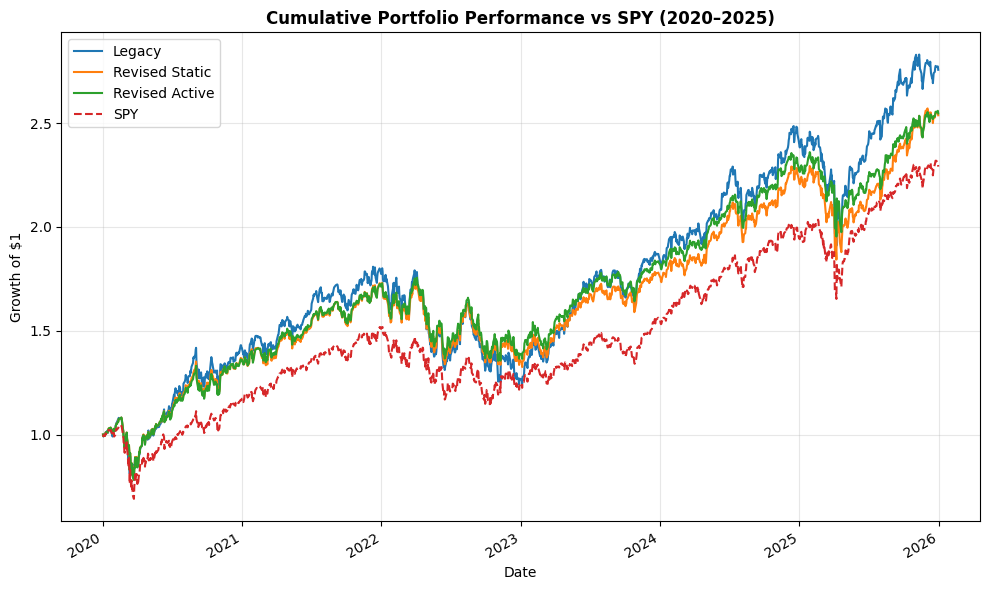

In [104]:
import matplotlib.pyplot as plt
import pandas as pd

bt = pd.read_csv("../outputs/tables/tbl_backtest_legacy_static_active_benchmark.csv")
bt["date"] = pd.to_datetime(bt["date"])
bt = bt.set_index("date")

plot_df = bt[[
    "legacy_growth_of_1_oos",
    "revised_static_growth_of_1",
    "revised_active_growth_of_1",
    "benchmark_growth_of_1"
]].copy()

# optional: rename for cleaner legend
plot_df.columns = ["Legacy", "Revised Static", "Revised Active", "SPY"]

# rebase (if not already done)
plot_df = plot_df / plot_df.iloc[0]

ax = plot_df.plot(figsize=(10,6), linewidth=1.5)

# make SPY dashed
ax.lines[-1].set_linestyle("--")

plt.title("Cumulative Portfolio Performance vs SPY (2020–2025)", fontweight="bold")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

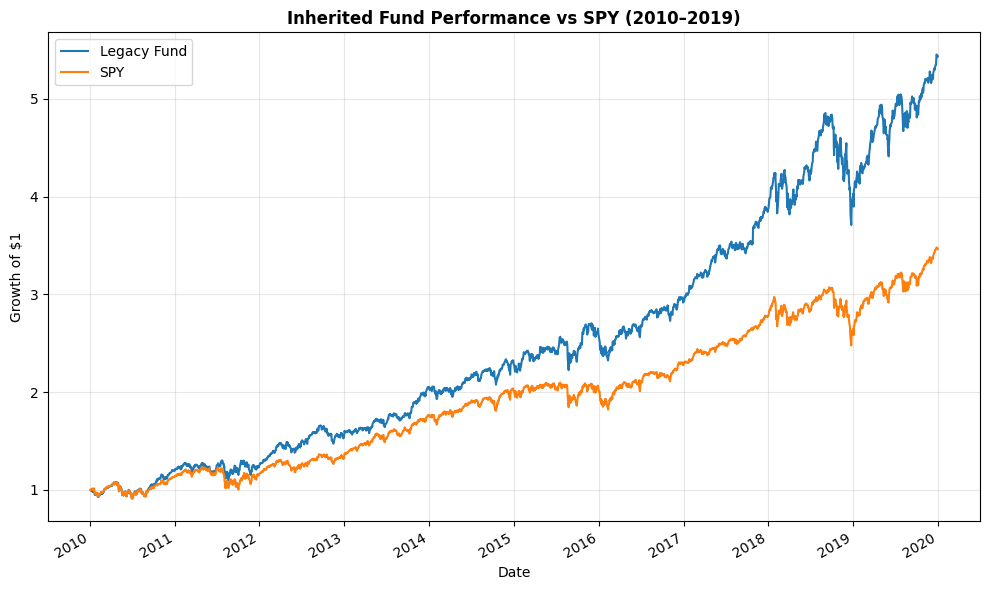

In [111]:
import pandas as pd
import matplotlib.pyplot as plt

legacy = pd.read_csv("../outputs/tables/tbl_legacy_fund_daily.csv")
prices = pd.read_csv("../data/clean/prices_adjclose_daily.csv")

legacy["date"] = pd.to_datetime(legacy["date"])
prices["Date"] = pd.to_datetime(prices["Date"])

legacy = legacy.set_index("date").loc["2010-01-04":"2019-12-31"]
prices = prices.set_index("Date").loc["2010-01-04":"2019-12-31"]

plot_df = pd.DataFrame({
    "Legacy Fund": legacy["legacy_growth_of_1"] / legacy["legacy_growth_of_1"].iloc[0],
    "SPY": prices["SPY"] / prices["SPY"].iloc[0]
})

ax = plot_df.plot(figsize=(10,6), linewidth=1.5)
#ax.lines[-1].set_linestyle("--")

plt.title("Inherited Fund Performance vs SPY (2010–2019)", fontweight="bold")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [112]:
import pandas as pd

legacy = pd.read_csv("../outputs/tables/tbl_legacy_fund_daily.csv")
legacy["date"] = pd.to_datetime(legacy["date"])
legacy = legacy.set_index("date")

In [115]:
legacy_is = legacy.loc["2010-01-04":"2019-12-31"]
r = legacy_is["legacy_fund_return"]

import numpy as np

ann_return = (1 + r).prod()**(252/len(r)) - 1
ann_vol = r.std() * np.sqrt(252)
sharpe = ann_return / ann_vol

# Sortino
downside = r[r < 0]
sortino = ann_return / (downside.std() * np.sqrt(252))

# Max drawdown
cum = (1 + r).cumprod()
peak = cum.cummax()
drawdown = (cum - peak) / peak
max_dd = drawdown.min()

# Total return & ending value
total_return = cum.iloc[-1] - 1
ending_value = cum.iloc[-1] * 1_000_000  # assuming $1M start

pd.DataFrame([{
    "portfolio": "Legacy Fund (2010–2019)",
    "ending_value": ending_value,
    "total_return": total_return,
    "ann_return": ann_return,
    "ann_vol": ann_vol,
    "sharpe": sharpe,
    "sortino": sortino,
    "max_drawdown": max_dd,
    "turnover": 0.0
}])

,portfolio,ending_value,total_return,ann_return,ann_vol,sharpe,sortino,max_drawdown,turnover
0,Legacy Fund (2010–2019),5.437812e+06,4.437812,0.184839,0.166489,1.110218,1.480822,-0.235931,0.0


In [116]:
import pandas as pd
import matplotlib.pyplot as plt

# Load legacy stock stats and candidate screen
legacy = pd.read_csv("../outputs/tables/tbl_audit_stock_stats.csv")
candidates = pd.read_csv("../outputs/tables/tbl_candidate_screen.csv")

print("Legacy columns:", legacy.columns.tolist())
print("Candidate columns:", candidates.columns.tolist())

Legacy columns: ['ticker', 'total_return', 'ann_return', 'ann_vol', 'sharpe', 'sortino', 'max_drawdown', 'alpha_ann', 'beta', 'r_squared', 'corr_to_spy', 'avg_pairwise_corr', 'return_1y', 'return_3y', 'weight_start', 'weight_end']
Candidate columns: ['candidate_ticker', 'download_ticker', 'company_name', 'sector_theme', 'thesis_1line', 'screening_note', 'add_decision', 'selected_for_final', 'status', 'first_date', 'last_date', 'n_obs', 'total_return_pre2020', 'ann_return_pre2020', 'ann_vol_pre2020', 'sharpe_pre2020', 'max_drawdown_pre2020', 'return_1y_pre2020', 'return_3m_pre2020', 'vol_63d_pre2020', 'current_drawdown_pre2020', 'corr_to_legacy_pre2020', 'corr_to_benchmark_pre2020', 'beta_to_benchmark_pre2020', 'notes']


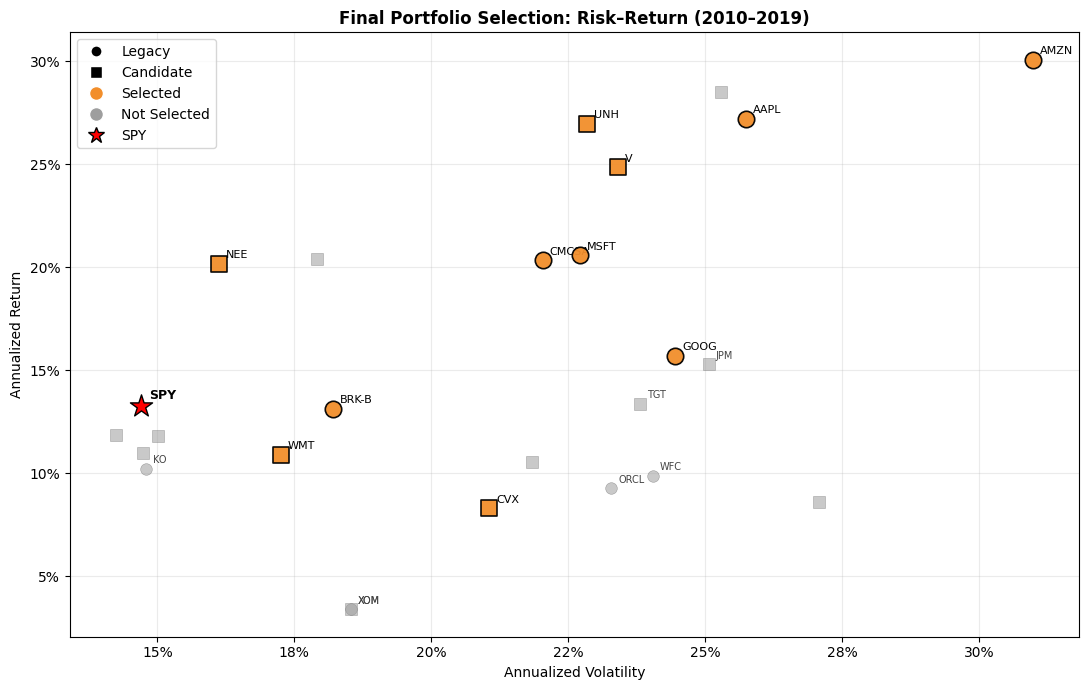

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- Load data ---
legacy = pd.read_csv("../outputs/tables/tbl_audit_stock_stats.csv")
candidates = pd.read_csv("../outputs/tables/tbl_candidate_screen.csv")
prices = pd.read_csv("../data/clean/prices_adjclose_daily.csv")

prices["Date"] = pd.to_datetime(prices["Date"])
prices = prices.set_index("Date")

# --- SPY stats (2010–2019) ---
spy = prices.loc["2010-01-04":"2019-12-31", "SPY"].pct_change().dropna()
spy_ann_return = (1 + spy).prod() ** (252 / len(spy)) - 1
spy_ann_vol = spy.std() * np.sqrt(252)

# --- Legacy ---
legacy_plot = legacy[["ticker", "ann_return", "ann_vol"]].copy()
legacy_plot["source"] = "Legacy"
legacy_plot["selected"] = False

# --- Candidates ---
candidate_plot = candidates[
    ["candidate_ticker", "ann_return_pre2020", "ann_vol_pre2020", "selected_for_final"]
].copy()

candidate_plot = candidate_plot.rename(columns={
    "candidate_ticker": "ticker",
    "ann_return_pre2020": "ann_return",
    "ann_vol_pre2020": "ann_vol",
})

candidate_plot["source"] = "Candidate"
candidate_plot["selected"] = candidate_plot["selected_for_final"].astype(str).str.lower().eq("yes")

# --- Combine ---
plot_df = pd.concat([
    legacy_plot[["ticker", "ann_return", "ann_vol", "source", "selected"]],
    candidate_plot[["ticker", "ann_return", "ann_vol", "source", "selected"]],
], ignore_index=True)

plot_df["ann_return"] = pd.to_numeric(plot_df["ann_return"], errors="coerce")
plot_df["ann_vol"] = pd.to_numeric(plot_df["ann_vol"], errors="coerce")
plot_df = plot_df.dropna(subset=["ann_return", "ann_vol"])

# --- Final selected names ---
final_names = {"AAPL", "AMZN", "BRK-B", "CMCSA", "GOOG", "MSFT", "NEE", "UNH", "V", "WMT"}
plot_df.loc[plot_df["ticker"].isin(final_names), "selected"] = True

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 7))

selected_color = "#F28E2B"
not_selected_color = "#9E9E9E"

# Plot points
for source, marker in [("Legacy", "o"), ("Candidate", "s")]:
    for sel, color in [(False, not_selected_color), (True, selected_color)]:
        d = plot_df[(plot_df["source"] == source) & (plot_df["selected"] == sel)]

        ax.scatter(
            d["ann_vol"],
            d["ann_return"],
            marker=marker,
            s=140 if sel else 70,
            color=color,
            edgecolor="black" if sel else "#666666",
            linewidth=1.2 if sel else 0.4,
            alpha=0.95 if sel else 0.55,
            zorder=4 if sel else 2
        )

# --- SPY ---
ax.scatter(
    spy_ann_vol,
    spy_ann_return,
    marker="*",
    s=280,
    color="red",
    edgecolor="black",
    linewidth=1,
    zorder=6
)

ax.annotate(
    "SPY",
    (spy_ann_vol, spy_ann_return),
    xytext=(6, 5),
    textcoords="offset points",
    fontsize=9,
    fontweight="bold"
)

# --- Labels: selected only ---
selected_points = plot_df[plot_df["selected"]]
for _, row in selected_points.iterrows():
    ax.annotate(
        row["ticker"],
        (row["ann_vol"], row["ann_return"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8
    )

# --- Labels: key dropped ---
dropped_labels = {"XOM", "KO", "ORCL", "WFC", "JPM", "TGT"}
dropped_points = plot_df[
    (~plot_df["selected"]) & (plot_df["ticker"].isin(dropped_labels))
]

for _, row in dropped_points.iterrows():
    ax.annotate(
        row["ticker"],
        (row["ann_vol"], row["ann_return"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=7,
        color="#444444"
    )

# --- Custom legend ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Legacy', markerfacecolor='black', markersize=8),
    Line2D([0], [0], marker='s', color='w', label='Candidate', markerfacecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Selected', markerfacecolor=selected_color, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Not Selected', markerfacecolor=not_selected_color, markersize=10),
    Line2D([0], [0], marker='*', color='w', label='SPY', markerfacecolor='red', markeredgecolor='black', markersize=12),
]

ax.legend(handles=legend_elements, frameon=True)

# --- Formatting ---
ax.set_title("Final Portfolio Selection: Risk–Return (2010–2019)", fontweight="bold")
ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Annualized Return")

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("../outputs/figures/fig_final_selection_clean.png", dpi=200, bbox_inches="tight")
plt.show()